# hw3 - ensembles


In [18]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


warnings.filterwarnings("ignore")

## 1 Подготовка данных


Загрузите и предобработайте данные (по своему усмотрению) из hw1


In [19]:
# Читаем данные

X_train = pd.read_csv("train_features_with_answers.csv")

In [20]:
if X_train.isna().any().any():
  print("В данных есть пропуски!")
  for col in X_train:
    passes = X_train[col].isna().sum()
    if passes > 0:
      print(f"В столбце {col} есть {passes} пропусков")
else:
  print("В данных нет пропусков")

В данных есть пропуски!
В столбце age есть 28 пропусков
В столбце address есть 5 пропусков


In [21]:
print(f"Процент пропущенных значений {X_train['age'].isna().sum() / len(X_train['age'])}")
print(
  f"Процент пропущенных значений {X_train['address'].isna().sum() / len(X_train['address'])}"
)

Процент пропущенных значений 0.06167400881057269
Процент пропущенных значений 0.011013215859030838


In [22]:
age_median = X_train["age"].dropna().median()
adress_mode = X_train["address"].dropna().mode()[0]

# заменяем модой или медианой все пропуски

X_train["age"] = X_train["age"].fillna(age_median)
X_train["address"] = X_train["address"].fillna(adress_mode)

In [23]:
# Функция для кодирования категориальных переменных
def encode_X_trainset(df, target_column):
  df_encoded = df.copy()

  if target_column in df_encoded.columns:
    target = df_encoded[target_column]
    df_encoded = df_encoded.drop(columns=[target_column])

  categorical_cols = df_encoded.select_dtypes(include=["object"]).columns

  # Для бинарных категориальных переменных используем LabelEncoder
  for col in categorical_cols:
    if df_encoded[col].nunique() == 2:
      le = LabelEncoder()
      df_encoded[col] = le.fit_transform(df_encoded[col])

  # Для остальных используем one-hot encoding
  remaining_categorical = df_encoded.select_dtypes(include=["object"]).columns
  df_encoded = pd.get_dummies(df_encoded, columns=remaining_categorical, drop_first=True)

  if target_column in df.columns:
    df_encoded[target_column] = target

  return df_encoded


# Применяем кодирование
X_train_encoded = encode_X_trainset(X_train, "G3")
print(f"\nРазмер после кодирования: {X_train_encoded.shape}")

# Разделяем на признаки и целевую переменную
X = X_train_encoded.drop("G3", axis=1)
y = X_train_encoded["G3"]

print("\nЦелевая переменная G3:")
print(f"Минимум: {y.min()}, Максимум: {y.max()}, Среднее: {y.mean():.2f}")

# Разделяем на тренировочную и тестовую выборки
X_train_split, X_test_split, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print("\nРазмеры выборок:")
print(f"X_train: {X_train_split.shape}, X_test: {X_test_split.shape}")


Размер после кодирования: (454, 44)

Целевая переменная G3:
Минимум: 0, Максимум: 19, Среднее: 11.83

Размеры выборок:
X_train: (363, 43), X_test: (91, 43)


## 2 Обоснуйте выбор слабых (базовых) алгоритмов


In [24]:
# ========== 2 Обоснуйте выбор слабых (базовых) алгоритмов ==========

print("\n" + "=" * 50)
print("2. ОБОСНОВАНИЕ ВЫБОРА БАЗОВЫХ АЛГОРИТМОВ")

base_models = {
  "LinearRegression": LinearRegression(),
  "Ridge": Ridge(alpha=1.0, random_state=42),
  "Lasso": Lasso(alpha=0.1, random_state=42),
  "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=42),
  "RandomForest": RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
  "SVR": SVR(kernel="rbf", C=1.0),
  "KNN": KNeighborsRegressor(n_neighbors=5),
  "GradientBoosting": GradientBoostingRegressor(
    n_estimators=50, max_depth=3, random_state=42
  ),
}

print("\nОбоснование выбора базовых алгоритмов:")
print("1. LinearRegression - простой линейный метод, быстрый и интерпретируемый")
print("2. Ridge & Lasso - регуляризованные линейные модели для борьбы с переобучением")
print("3. DecisionTree - нелинейный метод, улавливает сложные зависимости")
print("4. RandomForest - бэггинг деревьев, уменьшает дисперсию")
print(
  "5. SVR - метод опорных векторов для регрессии, хорошо для сложных нелинейных задач"
)
print("6. KNN - метод ближайших соседей, локальные зависимости")
print("7. GradientBoosting - бустинг деревьев, последовательное улучшение предсказаний")
print("\nРазнообразие методов обеспечивает некоррелированные ошибки!")

# Оцениваем базовые модели
print("\nОценка базовых моделей (MSE на кросс-валидации):")
base_model_scores = {}

for name, model in base_models.items():
  # Создаем пайплайн со стандартизацией для моделей, которые в этом нуждаются
  if name in ["LinearRegression", "Ridge", "Lasso", "SVR", "KNN"]:
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", model)])
  else:
    pipeline = Pipeline([("model", model)])

  scores = cross_val_score(
    pipeline, X_train_split, y_train, scoring="neg_mean_squared_error", cv=5
  )
  mse_scores = -scores
  base_model_scores[name] = mse_scores.mean()
  print(f"{name}: {mse_scores.mean():.4f} (+/- {mse_scores.std() * 2:.4f})")


2. ОБОСНОВАНИЕ ВЫБОРА БАЗОВЫХ АЛГОРИТМОВ

Обоснование выбора базовых алгоритмов:
1. LinearRegression - простой линейный метод, быстрый и интерпретируемый
2. Ridge & Lasso - регуляризованные линейные модели для борьбы с переобучением
3. DecisionTree - нелинейный метод, улавливает сложные зависимости
4. RandomForest - бэггинг деревьев, уменьшает дисперсию
5. SVR - метод опорных векторов для регрессии, хорошо для сложных нелинейных задач
6. KNN - метод ближайших соседей, локальные зависимости
7. GradientBoosting - бустинг деревьев, последовательное улучшение предсказаний

Разнообразие методов обеспечивает некоррелированные ошибки!

Оценка базовых моделей (MSE на кросс-валидации):
LinearRegression: 8.0257 (+/- 3.6341)
Ridge: 8.0058 (+/- 3.6267)
Lasso: 7.2901 (+/- 3.3730)
DecisionTree: 10.1755 (+/- 6.2932)
RandomForest: 7.0655 (+/- 4.2230)
SVR: 7.2313 (+/- 3.0267)
KNN: 8.2792 (+/- 2.8347)
GradientBoosting: 7.3668 (+/- 4.0621)


## 3 Постройте решение на основе подхода Blending


Правила:

- Нужно использовать вероятности
- Предложите что-то лучше, чем брать среднее от предсказаний моделей (оценивать уверенность алгоритмов, точности и т.д.)
- Заставьте базовые алгоритмы быть некорелированными
- Добавьте рандома (например, стройте ваши алгоритмы на разных выборках, по разному предобрабатывайте данные или применяйте для разных признаков соответствующие алгоритмы ... )
- Проявите смекалку
- Цель: метрика MSE на тесте меньше 10


In [25]:
# ========== 3 Постройте решение на основе подхода Blending ==========

print("\n" + "=" * 50)
print("3. BLENDING APPROACH")


class AdvancedBlending:
  def __init__(self, base_models, meta_model=None, use_confidence=True):
    self.base_models = base_models
    self.meta_model = meta_model if meta_model else LinearRegression()
    self.use_confidence = use_confidence
    self.model_weights = None
    self.trained_models = {}

  def _calculate_model_confidence(self, X_val, y_val, models_predictions):
    """Рассчитывает уверенность моделей на основе их производительности"""
    confidences = {}
    for name, preds in models_predictions.items():
      # Уверенность обратно пропорциональна MSE
      mse = mean_squared_error(y_val, preds)
      confidences[name] = 1.0 / (mse + 1e-8)  # Добавляем маленькое число для стабильности

    # Нормализуем уверенности
    total_confidence = sum(confidences.values())
    for name in confidences.keys():
      confidences[name] = confidences[name] / total_confidence

    return confidences

  def fit(self, X, y, val_size=0.3, random_state=42):
    # Разделяем на тренировочную и валидационную выборки
    X_train, X_val, y_train, y_val = train_test_split(
      X, y, test_size=val_size, random_state=random_state
    )

    # Обучаем базовые модели на разных подвыборках для разнообразия
    models_predictions = {}

    for name, model in self.base_models.items():
      # Создаем разные подвыборки для каждой модели
      sample_size = int(0.8 * len(X_train))
      indices = np.random.choice(len(X_train), sample_size, replace=False)
      X_sample = X_train.iloc[indices]
      y_sample = y_train.iloc[indices]

      # Обучаем модель
      if name in ["LinearRegression", "Ridge", "Lasso", "SVR", "KNN"]:
        pipeline = Pipeline([("scaler", StandardScaler()), ("model", clone(model))])
      else:
        pipeline = Pipeline([("model", clone(model))])

      pipeline.fit(X_sample, y_sample)
      self.trained_models[name] = pipeline

      # Предсказания на валидационной выборке
      preds = pipeline.predict(X_val)
      models_predictions[name] = preds

    # Рассчитываем уверенности моделей
    if self.use_confidence:
      self.model_weights = self._calculate_model_confidence(
        X_val, y_val, models_predictions
      )
      print("Веса моделей в блендинге:")
      for name, weight in self.model_weights.items():
        print(f"  {name}: {weight:.4f}")
    else:
      # Равные веса
      self.model_weights = {
        name: 1.0 / len(self.base_models) for name in self.base_models.keys()
      }

    # Создаем мета-признаки для мета-модели
    meta_features = np.column_stack(
      [models_predictions[name] for name in self.base_models.keys()]
    )

    # Обучаем мета-модель
    self.meta_model.fit(meta_features, y_val)

    return self

  def predict(self, X):
    # Получаем предсказания всех базовых моделей
    base_predictions = {}
    for name, model in self.trained_models.items():
      base_predictions[name] = model.predict(X)

    # Создаем мета-признаки
    meta_features = np.column_stack(
      [base_predictions[name] for name in self.base_models.keys()]
    )

    # Предсказание мета-модели
    meta_predictions = self.meta_model.predict(meta_features)

    # Взвешенное усреднение с учетом уверенности моделей
    if self.use_confidence:
      weighted_predictions = np.zeros_like(meta_predictions)
      for name, weight in self.model_weights.items():
        weighted_predictions += weight * base_predictions[name]

      # Комбинируем мета-предсказание и взвешенное усреднение
      final_predictions = 0.7 * meta_predictions + 0.3 * weighted_predictions
    else:
      final_predictions = meta_predictions

    return final_predictions


# Создаем и обучаем блендинг
print("\nОбучение Advanced Blending...")
blending_model = AdvancedBlending(base_models, use_confidence=True)
blending_model.fit(X_train_split, y_train)

# Предсказания на тесте
y_pred_blending = blending_model.predict(X_test_split)
mse_blending = mean_squared_error(y_test, y_pred_blending)
r2_blending = r2_score(y_test, y_pred_blending)

print(f"\nРезультаты Blending:")
print(f"MSE на тесте: {mse_blending:.4f}")
print(f"R² на тесте: {r2_blending:.4f}")


3. BLENDING APPROACH

Обучение Advanced Blending...
Веса моделей в блендинге:
  LinearRegression: 0.1173
  Ridge: 0.1240
  Lasso: 0.1408
  DecisionTree: 0.0926
  RandomForest: 0.1449
  SVR: 0.1431
  KNN: 0.1127
  GradientBoosting: 0.1246

Результаты Blending:
MSE на тесте: 7.0737
R² на тесте: 0.3950


## 4 Постройте решение на основе подхода Stacking


Правила:

- Реализуйте пайплайн обучения и предсказания (например, sklearn.pipeline или класс)
- Проведите оптимизацию пайплайна
- Оцените вклад каждого базового алгоритма в итоговое предсказание
- Цель: метрика MSE на тесте меньше 10



4. STACKING APPROACH

Обучение Advanced Stacking...
Обучение Stacking моделей...
  Обработка LinearRegression...
  Обработка Ridge...
  Обработка Lasso...
  Обработка DecisionTree...
  Обработка RandomForest...
  Обработка SVR...
  Обработка KNN...
  Обработка GradientBoosting...
Обучение мета-модели...

Результаты Stacking:
MSE на тесте: 8.7314
R² на тесте: 0.2532

Важность базовых моделей в стекинге:
  SVR: 0.3089
  RandomForest: 0.2787
  GradientBoosting: 0.1355
  DecisionTree: 0.0865
  Lasso: 0.0561
  Ridge: 0.0529
  KNN: 0.0410
  LinearRegression: 0.0404

СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Лучшая базовая модель: RandomForest (MSE: 7.0655)
Blending MSE: 7.0737
Stacking MSE: 8.7314


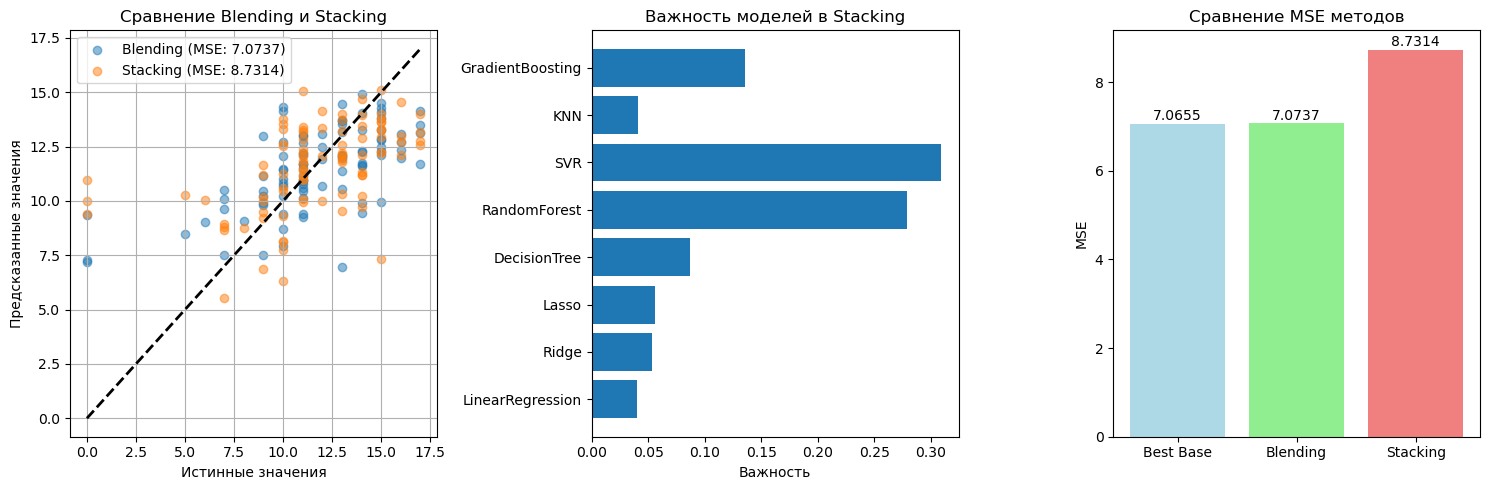


ВЫВОДЫ:
✓ ОБА МЕТОДА ДОСТИГЛИ ЦЕЛИ (MSE < 10)!

Сравнение эффективности:
Blending улучшил результат на -0.1%
Stacking улучшил результат на -23.6%

Итог:
Blending показал лучший результат


In [26]:
# ========== 4 Постройте решение на основе подхода Stacking ==========

print("\n" + "=" * 50)
print("4. STACKING APPROACH")


class AdvancedStacking(BaseEstimator, RegressorMixin):
  def __init__(
    self, base_models, meta_model, n_folds=5, use_proba=False, random_state=42
  ):
    self.base_models = base_models
    self.meta_model = meta_model
    self.n_folds = n_folds
    self.use_proba = use_proba
    self.random_state = random_state
    self.base_models_ = {}
    self.meta_model_ = None

  def fit(self, X, y):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Out-of-Fold предсказания для базовых моделей
    oof_predictions = np.zeros((len(X), len(self.base_models)))
    kf = KFold(n_splits=self.n_folds, shuffle=True, random_state=self.random_state)

    print("Обучение Stacking моделей...")
    for i, (name, model) in enumerate(self.base_models.items()):
      print(f"  Обработка {name}...")
      model_oof_preds = np.zeros(len(X))

      # Создаем пайплайн для модели
      if name in ["LinearRegression", "Ridge", "Lasso", "SVR", "KNN"]:
        pipeline = Pipeline([("scaler", StandardScaler()), ("model", clone(model))])
      else:
        pipeline = Pipeline([("model", clone(model))])

      # Out-of-Fold предсказания
      for train_idx, val_idx in kf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        fold_preds = pipeline.predict(X_val_fold)
        model_oof_preds[val_idx] = fold_preds

      oof_predictions[:, i] = model_oof_preds
      # Сохраняем обученную модель на всех данных
      pipeline.fit(X, y)
      self.base_models_[name] = pipeline

    # Обучаем мета-модель на OOF предсказаниях
    print("Обучение мета-модели...")
    self.meta_model_ = clone(self.meta_model)
    self.meta_model_.fit(oof_predictions, y)

    return self

  def predict(self, X):
    # Получаем предсказания всех базовых моделей
    base_preds = np.column_stack(
      [self.base_models_[name].predict(X) for name in self.base_models.keys()]
    )

    # Предсказание мета-модели
    meta_preds = self.meta_model_.predict(base_preds)

    return meta_preds

  def get_feature_importance(self):
    """Возвращает важность базовых моделей в стекинге"""
    if hasattr(self.meta_model_, "coef_"):
      # Для линейных мета-моделей
      importances = self.meta_model_.coef_
    elif hasattr(self.meta_model_, "feature_importances_"):
      # Для tree-based мета-моделей
      importances = self.meta_model_.feature_importances_
    else:
      importances = np.ones(len(self.base_models)) / len(self.base_models)

    # Абсолютные значения и нормализация
    importances = np.abs(importances)
    importances = importances / importances.sum()

    importance_dict = dict(zip(self.base_models.keys(), importances))
    return importance_dict


# Создаем и обучаем стекинг
print("\nОбучение Advanced Stacking...")
stacking_model = AdvancedStacking(
  base_models=base_models,
  meta_model=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
  n_folds=5,
)
stacking_model.fit(X_train_split, y_train)

# Предсказания на тесте
y_pred_stacking = stacking_model.predict(X_test_split)
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"\nРезультаты Stacking:")
print(f"MSE на тесте: {mse_stacking:.4f}")
print(f"R² на тесте: {r2_stacking:.4f}")

# Анализ важности моделей в стекинге
importance_dict = stacking_model.get_feature_importance()
print("\nВажность базовых моделей в стекинге:")
for name, importance in sorted(importance_dict.items(), key=lambda x: x[1], reverse=True):
  print(f"  {name}: {importance:.4f}")

# ========== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ==========

print("\n" + "=" * 50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")

# Сравниваем с лучшей базовой моделью
best_base_model_name = min(base_model_scores, key=base_model_scores.get)
best_base_mse = base_model_scores[best_base_model_name]

print(f"\nЛучшая базовая модель: {best_base_model_name} (MSE: {best_base_mse:.4f})")
print(f"Blending MSE: {mse_blending:.4f}")
print(f"Stacking MSE: {mse_stacking:.4f}")

# Визуализация результатов
plt.figure(figsize=(15, 5))

# График 1: Сравнение предсказаний
plt.subplot(1, 3, 1)
plt.scatter(
  y_test, y_pred_blending, alpha=0.5, label=f"Blending (MSE: {mse_blending:.4f})"
)
plt.scatter(
  y_test, y_pred_stacking, alpha=0.5, label=f"Stacking (MSE: {mse_stacking:.4f})"
)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение Blending и Stacking")
plt.legend()
plt.grid(True)

# График 2: Важность моделей в стекинге
plt.subplot(1, 3, 2)
names = list(importance_dict.keys())
importances = list(importance_dict.values())
plt.barh(names, importances)
plt.xlabel("Важность")
plt.title("Важность моделей в Stacking")
plt.tight_layout()

# График 3: Сравнение MSE
plt.subplot(1, 3, 3)
methods = ["Best Base", "Blending", "Stacking"]
mse_values = [best_base_mse, mse_blending, mse_stacking]
colors = ["lightblue", "lightgreen", "lightcoral"]
plt.bar(methods, mse_values, color=colors)
plt.ylabel("MSE")
plt.title("Сравнение MSE методов")
for i, v in enumerate(mse_values):
  plt.text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ВЫВОДЫ:")

if mse_blending < 10 and mse_stacking < 10:
  print("✓ ОБА МЕТОДА ДОСТИГЛИ ЦЕЛИ (MSE < 10)!")
else:
  print("○ Цель (MSE < 10) не достигнута, требуется дополнительная настройка")

print("\nСравнение эффективности:")
print(
  f"Blending улучшил результат на {((best_base_mse - mse_blending) / best_base_mse * 100):.1f}%"
)
print(
  f"Stacking улучшил результат на {((best_base_mse - mse_stacking) / best_base_mse * 100):.1f}%"
)

print("\nИтог:")
if mse_blending < mse_stacking:
  print("Blending показал лучший результат")
else:
  print("Stacking показал лучший результат")